# E-Commerce Agentic Bots
1. 📦 Global Products Agent
- `Tools:` Web Scrapes from popular webpages such as Amazon, Spotify in `json-like format`
- `Description:` Writes a description about each product as well as their price, adhers to a specific pydantic format
- `PDF:` Saves Description about each item in a single PDF report, that can be vectorised and stored in a `vector database`

2. 🐼Chinese Latest Trend Agent
- `Tools:` API tools that fetches in `json-like format` or use `Tarvily` for web search smartly, an optimisted web-search library for LLM
- `Description:` Writes a summary about the latest news in china regarding products, general trends
- `PDF:` Saves the summary in a single PDF report, that can be vectorised and stored in a `vector database`

3. 🏛️📜Chinese Legal Platform, Commerical, Legal laws Agent
- `Tools:` uses `Tarvily` for web search smartly
- `Description:` Saves all these legal laws in a single document without reading them
- `PDF:` Saves all legal information in a single PDF report, that can be vectorised and stored in a `vector database`

4. ⛩️Chinese Cultural Nuance Creator Agent
- `Tools:` Access all PDF reports using `RAG` to generate a general report for chinese audience
- `PDF:` Saves a PDF report, that can be vectorised and stored in a `vector database`

5. 🎥Platform Specific Agent
- `Tools:` Access PDF generated by `Chinese Cultural Nuance Creator Agent` using `RAG` technique
- `Generation:` Generates a script for each specific platform separately

6. 🏮Translator Agent
- `Tools:` Access PDF generated by  Platform Specific Agent, translates it into several chinese dialects including Mandarin

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from pydantic import BaseModel, Field
from typing import List, Literal, Optional, Dict, Any
from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import add_messages
import operator
from requests import request
from bs4 import BeautifulSoup
from html_to_markdown import convert
import time


class Product(BaseModel):
    name: str
    price: float
    description: str
    category: str | None = Field(
        description="The product category extracted from the webpage. If not explicitly mentioned, generate a suitable, general category name."
    )    
    rating: float | None = Field(description="extract the rating of the product if it only exists, , that comes from the content of the webpage, do not make it up")
    source_address: str | None = Field(description="The URL or physical address where this content was extracted.")

class ProductCatalog(BaseModel):
    products : List[Product] = Field(description="A list of e-commerce products")

class ProductSchema(BaseModel):
    type_url_data : Literal["json","html","txt","csv"] = Field(description="Based on current_url if it has api word in it assume it returns 'json' , if it is a normal webpage assume it returns 'html' , if it text file e.g. data.txt then return 'txt', if its data.csv return 'csv'")
    url_list : list[str] = Field(description="given a message extract urls and datasets csv/txt only from that message and store them in array")
    work_status: Literal["inprogress","finished"] = Field(description="If processed_url_list is equal to url_list return 'finished' else 'inprogress")
    processed_url_list: list[str] = Field(description="every current url that has been processed is to be added to this list")
    current_url: str = Field(description="pick current_url from url_list only do not take it from anywhere else")
class State(TypedDict):
    messages: Annotated[list[str], add_messages]
    products_list: Annotated[list[Product], operator.add]
    type_url_data: Literal["json","html"]
    current_url: str
    url_list : list[str]
    work_status: Literal["inprogress","finished"]
    processed_url_list: Annotated[list[str], operator.add]
    ########################################################
    # general information regarding performance, speed, time taken, error messages
    no_of_articles_extracted: int = 0
    error_messages : Annotated[list[str], add_messages]
    feedback_message : str



### LLM

In [3]:
from langchain.chat_models import init_chat_model

product_llm = init_chat_model(model="gemini-3.1-flash-lite", model_provider="google_genai")

### Classifer Functions

In [ ]:

def product_task_manager(state: State):
    print("product_task_manager() --> Analysis --->")
    print("============================================")
    print("len: processed_url_list",len(state["processed_url_list"]))
    print("len: url_list",len(state["url_list"]))
    print("url_list ",state["url_list"])
    print("url_list ",state["processed_url_list"])
    print("current_url ",state["current_url"])
    print("============================================")


    if len(state["processed_url_list"]) == len(state["url_list"]):
        work_status = "finished"
    else:
        work_status = "inprogress"

    return {"work_status":work_status}

def url_classifier(state: State):
    if state.get("url_list") is None:
        #Start Intialisation
        last_message = state["messages"][-1].content
        structured_output_llm = product_llm.with_structured_output(ProductSchema)
        msg = [
            {"role":"system","content":"extract all url only from user message and put them in url_list, then select a current_url from url_list, then determine type of data of that current_url"},
            {"role":"user","content":last_message}
        ]
        results = structured_output_llm.invoke(msg)
        
        return {
            "type_url_data": results.type_url_data,
            "url_list": results.url_list,
            "current_url": results.current_url
        }
    else:
        #Continue the work flow
        url_list = state["url_list"]
        processed_url_list = state["processed_url_list"]
        structured_output_llm = product_llm.with_structured_output(ProductSchema)
        msg = [
            {"role":"system","content":"select a current_url from url_list ONLY IF IT DOES NOT EXIST IN processed_url_list, then determine type of data of that current_url"},
            {"role":"user","content":f"url_list is {url_list} , processed_url_list is {processed_url_list}"}
        ]
        results = structured_output_llm.invoke(msg)
        
        return {
            "type_url_data": results.type_url_data,
            "current_url": results.current_url,
        }

### Routers

In [5]:
def url_router(state: State):
    return state["type_url_data"]

def task_manager_router(state: State):
    return state["work_status"]


### Helper Functions

In [6]:
import csv
import chardet
from pathlib import Path

FAIL="failed"
SUCCESS="success"


def handle_web_requests(url: str):
    try:
        respond = request(method="GET",url=url,timeout=2)
        if respond.status_code == 200:
            return (respond, SUCCESS)
        else:
            error_msg = f"Error Failed due to status_code in handle_web_requests Reason : {e}"
            return (error_msg, FAIL)
    except Exception as e:
        error_msg = f"Error Failed to handle_web_requests reason : {e}"
        return (error_msg, FAIL)

#################################################################
def get_encoding(filepath) -> str:
    """Given a filepath it will read it as binary text file to detect its encoding, note encoding detection is not 100% accurate"""
    with open(filepath,mode="rb") as file:
        raw_content_binary = file.read()
        result = chardet.detect(raw_content_binary)
        return result["encoding"]


def locate_file(filepath, allowed_time=30) -> Path | str:
    """given filepath it checks if it exists else it will search for file based on filename in current directory,
    then correct filepath"""

    file_path = Path(filepath)
    if file_path.is_file():
        return file_path
    else:
        target=file_path.name
        extension=file_path.suffix
        root = Path(Path.cwd())
        files_seen=0
        for file in root.rglob(f"*{extension}"):
            if file.is_file() and file.name == target:
                return file
            files_seen+=1
            if files_seen==allowed_time:
                return FAIL
    print(f"error does not exist {filepath}")
    return FAIL


In [ ]:

def fetch_api_data(state: Dict[str, Any]): #Dict instead of State so it accepts any state rather than a specific State Schema, so it can be reused
    current_url = state["current_url"]
    response, status_flag = handle_web_requests(current_url)
    if state.get("no_of_articles_extracted") is None:
        state["no_of_articles_extracted"] = 0
    count = state["no_of_articles_extracted"] + 1
    try:
        if status_flag == SUCCESS:
            return {"messages":[str(response.json())], "processed_url_list":[current_url], "no_of_articles_extracted":count}
        else:
            return {"error_messages":response}
    except Exception as e:
        return {"error_messages":f"error failed to fetch_api_data from {current_url} reason {e}"}

def fetch_html_data(state: State):
    current_url = state["current_url"]
    response, status_flag = handle_web_requests(current_url)
    if state.get("no_of_articles_extracted") is None:
        state["no_of_articles_extracted"] = 0
    count = state["no_of_articles_extracted"] + 1
    try:
        if status_flag == SUCCESS:
            exclude_tags=["script","head","title","style","svg","!doctype","meta"]
            soup =  BeautifulSoup(response.text, "html.parser")
            for tag in exclude_tags:
                    for match in soup.find_all(tag):
                        match.extract()
            return {"messages":[str(soup)], "processed_url_list":[current_url], "no_of_articles_extracted":count}
        else:
            return {"error_messages":response}
    except Exception as e:
        return {"error_messages":f"error failed to fetch html data from {current_url} reason {e}"}

def clean_to_markdown(state: State):
    """the cleaned html from fetch_raw_html() is then converted to markdown format"""
    html_content = state["messages"][-1].content
    markdown_object = convert(str(html_content))
    markdown = markdown_object.content
    return {"messages":markdown}

def extract_structured_data(state: State):
    """Given a markdown or json-like format or text paragraph as input, it is taken to extract products information according to pydantic Schema format"""
    content = state["messages"][-1].content
    structured_output_llm = product_llm.with_structured_output(ProductCatalog)
    msg = [
        {"role":"system","content":"extract the text from markdown or json-like format or text paragraph and give output in pydantic specified format"},
        {"role":"user","content":content}
    ]
    product_cat_object = structured_output_llm.invoke(msg)
    return {"products_list":product_cat_object.products}


def fetch_csv_file(state: State):
    """read file function csv, given encoding and filepath returns list"""
    file_path_string=state["current_url"]
    filepath = locate_file(file_path_string)
    correct_encoding = get_encoding(filepath)
    if state.get("no_of_articles_extracted") is None:
        state["no_of_articles_extracted"] = 0
    count = state["no_of_articles_extracted"] + 1
    with open(filepath,mode="r", encoding=correct_encoding) as file:
        reader = csv.DictReader(file,delimiter=",")
        data = list(reader)
        return {"messages":data, "processed_url_list":[file_path_string], "no_of_articles_extracted":count}
    
def fetch_text_file(state: State):
    """read file txt , given encoding, filepath returns string"""
    file_path_string=state["current_url"]
    filepath = locate_file(file_path_string)
    correct_encoding = get_encoding(filepath)
    if state.get("no_of_articles_extracted") is None:
        state["no_of_articles_extracted"] = 0
    count = state["no_of_articles_extracted"] + 1
    with open(filepath,mode="r", encoding=correct_encoding) as file:
        data = file.read()
        return {"messages":[data], "processed_url_list":[file_path_string], "no_of_articles_extracted":count}

In [8]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(State)
graph.add_node("fetch_html_data",fetch_html_data)
graph.add_node("fetch_api_data",fetch_api_data)
graph.add_node("clean_to_markdown",clean_to_markdown)
graph.add_node("extract_structured_data",extract_structured_data)
graph.add_node("url_classifier",url_classifier)
graph.add_node("fetch_csv_file",fetch_csv_file)
graph.add_node("fetch_text_file",fetch_text_file)
graph.add_node("product_task_manager",product_task_manager)
############################################################
graph.add_edge(START,"url_classifier")
graph.add_conditional_edges("url_classifier",
                            url_router,
                            {"json":"fetch_api_data","html":"fetch_html_data","txt":"fetch_text_file","csv":"fetch_csv_file"}
                            )
graph.add_edge("fetch_html_data","clean_to_markdown")
graph.add_edge("clean_to_markdown","extract_structured_data")
graph.add_edge("fetch_api_data","extract_structured_data")
graph.add_edge("fetch_text_file","extract_structured_data")
graph.add_edge("fetch_csv_file","extract_structured_data")
graph.add_edge("extract_structured_data","product_task_manager")

graph.add_conditional_edges("product_task_manager",
                            task_manager_router,
                            {"inprogress":"url_classifier","finished":END}
                            )

compiled_graph = graph.compile()

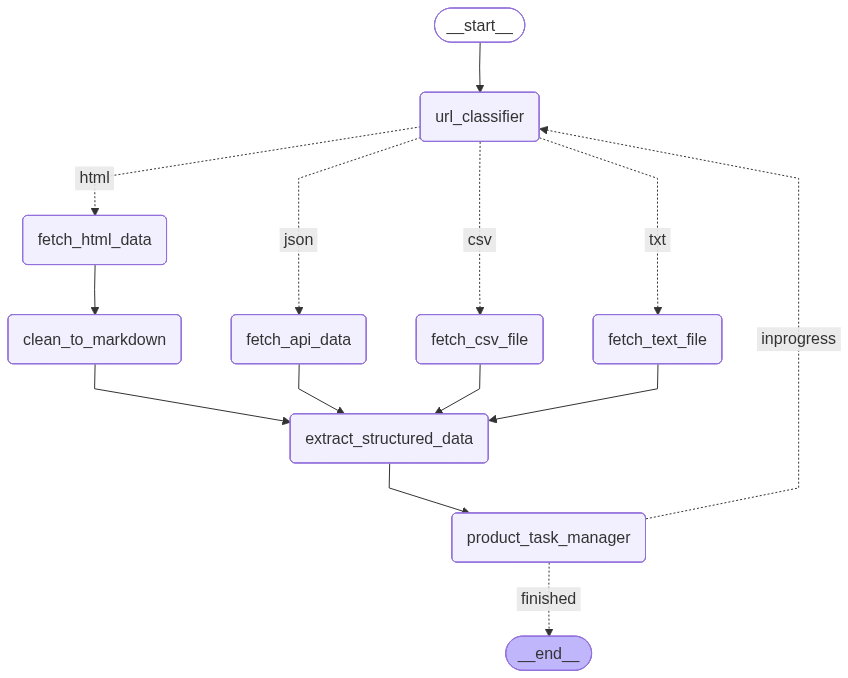

In [9]:
from IPython.display import Image

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

### Running

In [10]:
inputs = {
    "messages": [
        {
            "role": "user", 
            "content": "Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list, also extract data from this local file product_intelligence_report_v2.txt"
        }
    ]
}

compiled_graph.invoke(
inputs
)

product_task_manager() --> Analysis --->
len: processed_url_list 1
len: url_list 3
url_list  ['http://books.toscrape.com/', 'https://api.escuelajs.co/api/v1/products', 'product_intelligence_report_v2.txt']
url_list  ['http://books.toscrape.com/']
current_url  http://books.toscrape.com/
product_task_manager() --> Analysis --->
len: processed_url_list 2
len: url_list 3
url_list  ['http://books.toscrape.com/', 'https://api.escuelajs.co/api/v1/products', 'product_intelligence_report_v2.txt']
url_list  ['http://books.toscrape.com/', 'https://api.escuelajs.co/api/v1/products']
current_url  https://api.escuelajs.co/api/v1/products
product_task_manager() --> Analysis --->
len: processed_url_list 3
len: url_list 3
url_list  ['http://books.toscrape.com/', 'https://api.escuelajs.co/api/v1/products', 'product_intelligence_report_v2.txt']
url_list  ['http://books.toscrape.com/', 'https://api.escuelajs.co/api/v1/products', 'product_intelligence_report_v2.txt']
current_url  product_intelligence_repor

{'messages': [HumanMessage(content='Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list, also extract data from this local file product_intelligence_report_v2.txt', additional_kwargs={}, response_metadata={}, id='83e6a92a-e2a2-4696-9a15-41efd3168f5e'),
  HumanMessage(content='<!DOCTYPE html>\n\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->\n\n<body class="default" id="default">\n<header class="header container-fluid">\n<div class="page_inner">\n<div class="row">\n<div class="col-sm-8 h1"><a href="index.html">Books to Scrape</a><small> We love being scraped!</small>\

# Latest News Agent

1. Fetches Latests Global news regarding specific topic e.g. Electronics
2. Fetches Latests Chinese news regarding specific topic e.g. Electronics
3. Merges all these into a document, that is fed into model
4. Model is tasked to summary them up and write up to only 10 bullet points briefly then it is saved into a PDF

`API`
- Currents API: 1,000 requests per day
- GNews.io: 100 requests per day
- Tarvily: 1,000 free search credits per month

# New

### Article LLM


In [11]:
from langchain.chat_models import init_chat_model

article_llm = init_chat_model(model="gemini-3.1-flash-lite", model_provider="google_genai")

### Pydantic Models

In [12]:
class Article(BaseModel):
    description: str | None = Field(description="Description about the article")
    title: str | None = Field(description="Title of the article")
    content: str | None = Field(description="Content of the article")
    source_url: str | None = Field(description="Only the URL source of  the article")
    publishedAt: str | None = Field(description="the publishing date of the article in the following format YYYY-MM-DD",examples=["2026-06-21"])
    country_name: str | None = Field(description="Enter country name in full where the articles were searched", examples=["Egypt","Sudan"])

class ArticleList(BaseModel):
    articles : list[Article] = Field(description="A list of online articles")

class ArticleSummary(BaseModel):
    summary: str | None = Field(description=(
        "A detailed summary of the articles split into two distinct sections: "
        "make sure to write a subheader for each two distinct sections such as 'Global Articles Summary' then one for china articles 'Chinese Articles Summary'"
        "1. Up to 10 bullet points summarizing key themes and topics from all global countries. "
        "2. Up to 10 bullet points specifically summarizing themes and topics from China articles. "
        "The total response must contain a maximum of 20 bullet points."
        "3. write analysis summary: article's country of origin mention them all, also mention whether you found articles from china exclusively or not"
    ))
    

class ArticleSchema(BaseModel):
    url_list : list[str] = Field(description="given a message extract urls")
    processed_url_list: list[str] = Field(description="every current url that has been processed is to be added to this list")
    current_url: str = Field(description="pick current_url from url_list only do not take it from anywhere else")
    #########################################################################################################################
    work_status: Literal["inprogress","finished"] = Field(description="If processed_url_list is equal to url_list return 'finished' else 'inprogress")
    objective: str = Field(description="Based on user message, write a better search objective that will be used to determine whether articles are relevant to this user's object or not")



### Articles State

In [13]:
class ArticleState(TypedDict):
    messages: Annotated[list[str], add_messages]
    objective: str
    current_url: str
    url_list : list[str]
    work_status: Literal["inprogress","finished"]
    processed_url_list: Annotated[list[str], operator.add]
    articles_list: Annotated[list[Article], operator.add]
    summary: str
    ########################################################
    # general information regarding performance, speed, time taken, error messages
    no_of_articles_extracted: int = 0
    error_messages : Annotated[list[str], add_messages]
    feedback_message : str

### Helper Functions

In [14]:
from dotenv import load_dotenv
import os

load_dotenv()

def generate_gnews_url(topic,max,apikey,language="en",country=None):
    if country is None:
        #globally
        new_url=f"https://gnews.io/api/v4/search?q={topic}&lang={language}&max={max}&apikey={apikey}"
    else:
        #locally
        new_url=f"https://gnews.io/api/v4/search?q={topic}&country={country}&lang={language}&max={max}&apikey={apikey}"
    return new_url


def generate_current_news_url(topic,category,apikey,language="en",country=None):
    if country is None:
        #globally
        new_url = f'https://api.currentsapi.services/v1/search?keywords={topic}&category={category}&language={language}&apiKey={apikey}'

    else:
        #locally
        new_url = f'https://api.currentsapi.services/v1/search?keywords={topic}&category={category}&language={language}&country={country}&apiKey={apikey}'
    return new_url


GNEWS_API_KEY = os.environ["GNEWS_API_KEY"]
gnews_url_globally = generate_gnews_url("Technology",40,GNEWS_API_KEY)
gnews_url_locally = generate_gnews_url("Technology",40,GNEWS_API_KEY,country="cn")

CURRENT_NEWS_API_KEY = os.environ["CURRENT_NEWS_API_KEY"]
current_url_globally = generate_current_news_url("ai","technology",CURRENT_NEWS_API_KEY)
current_url_locally = generate_current_news_url("ai","technology",CURRENT_NEWS_API_KEY,country="cn")

In [ ]:
import requests
import json

r=requests.get(current_url_globally)
str(r.text)

'{"status":"ok","news":[{"id":"b7c9bf6b-9d18-5611-b552-1158710c8fc2","title":"Broadcom stock needs a win. The new OpenAI co-designed Jalapeno chip might do the trick","description":"The news involving OpenAI, the creator of ChatGPT, comes as Broadcom stock fights to get back on track.","url":"https://www.cnbc.com/2026/06/24/broadcom-stock-needs-a-win-the-new-openai-co-designed-jalapeno-chip-might-do-the-trick.html","author":"Zev Fima","image":"https://image.cnbcfm.com/api/v1/image/108240906-1765488899432-gettyimages-2247873891-porzycki-openaian251125_np8Yd.jpeg?v=1765488966&w=1920&h=1080","language":"en","category":["technology"],"source_category":["technology"],"published":"2026-06-24 17:48:20 +0000"},{"id":"e06f5c35-7d70-51ce-afcb-030dac7b63d5","title":"Google Home Speaker","description":"Google Home Speaker pros and cons. Liked: Compact design Great build quality Disliked: Premium features sit behind a subscription paywall","url":"http://www.techspot.com/products/audio-video/google-

In [ ]:
import json
json.e(r.text)

'{"status":"ok","news":[{"id":"b7c9bf6b-9d18-5611-b552-1158710c8fc2","title":"Broadcom stock needs a win. The new OpenAI co-designed Jalapeno chip might do the trick","description":"The news involving OpenAI, the creator of ChatGPT, comes as Broadcom stock fights to get back on track.","url":"https://www.cnbc.com/2026/06/24/broadcom-stock-needs-a-win-the-new-openai-co-designed-jalapeno-chip-might-do-the-trick.html","author":"Zev Fima","image":"https://image.cnbcfm.com/api/v1/image/108240906-1765488899432-gettyimages-2247873891-porzycki-openaian251125_np8Yd.jpeg?v=1765488966&w=1920&h=1080","language":"en","category":["technology"],"source_category":["technology"],"published":"2026-06-24 17:48:20 +0000"},{"id":"e06f5c35-7d70-51ce-afcb-030dac7b63d5","title":"Google Home Speaker","description":"Google Home Speaker pros and cons. Liked: Compact design Great build quality Disliked: Premium features sit behind a subscription paywall","url":"http://www.techspot.com/products/audio-video/google-

### Classifiers

In [15]:
def article_task_manager(state: State):
    print("article_task_manager() --> Analysis --->")
    print("============================================")
    print("len: processed_url_list",len(state["processed_url_list"]))
    print("len: url_list",len(state["url_list"]))
    print("url_list ",state["url_list"])
    print("url_list ",state["processed_url_list"])
    print("current_url ",state["current_url"])
    print("============================================")


    if len(state["processed_url_list"]) == len(state["url_list"]):
        work_status = "finished"
    else:
        work_status = "inprogress"

    return {"work_status":work_status}

### Nodes

In [42]:
def clarify_search_objective(state: ArticleState):
    print("clarify_search_objective starting...")
    last_message = state["messages"][-1].content
    if state.get("objective") is None:

        obj_articles_llm = article_llm.with_structured_output(ArticleSchema)
        msg=[
            {"role":"system","content":"Based on user message, write a better search objective that will be used to determine whether articles are relevant to this user's object or not"},
            {"role":"user","content":last_message}
        ]
        results = obj_articles_llm.invoke(msg)
    else:
            obj_articles_llm = article_llm.with_structured_output(ArticleSchema)
            msg=[
            {"role":"system","content":"only get current url that is not in processed_url_list, make sure you dont extract url from read articles only from url_list"},
            {"role":"user","content":last_message}
            ]
            results = obj_articles_llm.invoke(msg)
    if state.get("objective") is None:
        print(f"results in clarify_search_objective are {results}")
        return {"objective":results.objective,"url_list":results.url_list,"current_url":results.current_url,"work_status":results.work_status}
    else:
        return {"url_list":results.url_list,"current_url":results.current_url,"work_status":results.work_status}

def filter_relevant_articles(state: ArticleState):
    filter_articles_llm = article_llm.with_structured_output(ArticleList)
    msg=[
        {"role":"system","content":"filter the most relevant articles according to the user message, the one that are irrelevant do not include them, make sure not include duplicates of same articles, at least minimum have 10 unique articles in list"},
        {"role":"user","content":f"articles : {state["messages"][-1].content} objective: {state["objective"]}"}
    ]
    results = filter_articles_llm.invoke(msg)
    print("results are :",results)
    return {"articles_list":[results.articles]}

def summarise_articles(state: ArticleState):
    print("summarise_articles : articles")
    print(state["articles_list"])

    advice=(
          "A detailed summary of the articles split into two distinct sections: "
        "make sure to write a subheader for each two distinct sections such as 'Global Articles Summary' then one for china articles 'Chinese Articles Summary'"
        "1. Up to 10 bullet points summarizing key themes and topics from all global countries. "
        "2. Up to 10 bullet points specifically summarizing themes and topics from China articles. "
        "The total response must contain a maximum of 20 bullet points."
        "3. write analysis summary: article's country of origin mention them all, also mention whether you found articles from china exclusively or not"
    )

    summary_articles_llm = article_llm.with_structured_output(ArticleSummary)
    msg=[
        {"role":"system","content":advice},
        {"role":"user","content":f"articles : {state["articles_list"]} objective: {state["objective"]}"}
    ]
    results = summary_articles_llm.invoke(msg)
    print("results are :",results.summary)
    return {"summary":results.summary}

### Building Article Agent

In [43]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(ArticleState)
graph.add_node("clarify_search_objective",clarify_search_objective)
graph.add_node("fetch_api_data",fetch_api_data)
graph.add_node("filter_relevant_articles",filter_relevant_articles)
graph.add_node("summarise_articles",summarise_articles)
graph.add_node("article_task_manager",article_task_manager)
########################################################################
graph.add_edge(START,"clarify_search_objective")
graph.add_edge("clarify_search_objective","fetch_api_data")
graph.add_edge("fetch_api_data","filter_relevant_articles")
graph.add_edge("filter_relevant_articles","article_task_manager")
graph.add_conditional_edges("article_task_manager",
                            task_manager_router,
                            {"inprogress":"clarify_search_objective","finished":"summarise_articles"}
                            )
graph.add_edge("summarise_articles",END)

compiled_article_graph = graph.compile()

In [44]:
from IPython.display import Image

display(Image(compiled_article_graph.get_graph().draw_mermaid_png()))

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

### Running Article Agent

In [45]:

inputs = {
    "messages": [
        {
            "role": "user", 
            "content": f"use the following url globally {gnews_url_globally} and {current_url_globally} , locally in china is {gnews_url_locally} and {current_url_locally}, objective is : AI news"
        }
    ]
}

results = compiled_article_graph.invoke(
inputs
)

clarify_search_objective starting...
results in clarify_search_objective are url_list=['https://gnews.io/api/v4/search?q=Technology&lang=en&max=40&apikey=2c4adab63b9954a566cfc901a4174ac4', 'https://api.currentsapi.services/v1/search?keywords=ai&category=technology&language=en&apiKey=okHVF9KRbW0pbRrhliMO38vWEXIWqO9ESkCnaDQ0yQMnybEy', 'https://gnews.io/api/v4/search?q=Technology&country=cn&lang=en&max=40&apikey=2c4adab63b9954a566cfc901a4174ac4', 'https://api.currentsapi.services/v1/search?keywords=ai&category=technology&language=en&country=cn&apiKey=okHVF9KRbW0pbRrhliMO38vWEXIWqO9ESkCnaDQ0yQMnybEy'] processed_url_list=[] current_url='https://gnews.io/api/v4/search?q=Technology&lang=en&max=40&apikey=2c4adab63b9954a566cfc901a4174ac4' work_status='inprogress' objective='Identify and extract news articles focused on artificial intelligence developments, technological innovations, and AI-related advancements with a specific interest in both global trends and China-specific developments.'
resu

KeyboardInterrupt: 

In [40]:
results["summary"]

'Global Articles Summary: - Bitcoin experienced a price decline to $62,600 amid a broader market selloff in technology and AI stocks. - Investors are reassessing risk exposure in volatile assets due to central bank policies and liquidity concerns. - Cloudflare CEO Matthew Prince expressed concerns that AI agents could hinder small business competitiveness. - Autonomous AI systems are increasingly influencing consumer behavior and purchasing decisions. Chinese Articles Summary: - ByteDance, the parent company of TikTok, is reportedly seeking a $20 billion offshore loan. - Indian markets continue to restrict direct entry for Chinese electric vehicle manufacturers. - Despite market bans, Chinese EV technology is successfully entering the Indian market through supply chain partnerships and collaborations. Analysis Summary: The articles analyzed originate from Malaysia and India. I did not find articles exclusively from China; instead, the reports focus on Chinese entities like ByteDance an

In [41]:
results["articles_list"]

[[Article(description='June 24 (Reuters) - \u2060Chinese technology company ByteDance, \u2060the developer of TikTok, \u2001is in preliminary talks with banks for its largest offshore \u2001loan of about $20 billion, \u2060Bloomberg News \u2060reported on Wednesday, citing people \u2060familiar \u2001with the matter.', title='ByteDance seeks $20 billion in its largest-ever offshore loan, Bloomberg News reports', content='June 24 (Reuters) - \u2060Chinese technology company ByteDance, \u2060the developer of TikTok, \u2001is in preliminary talks with banks for its largest offshore \u2001loan of about $20 billion, \u2060Bloomberg News \u2060reported on Wednesday, citing people \u2060familiar \u2001with the ma... [453 chars]', source_url='https://www.thestar.com.my/tech/tech-news/2026/06/24/bytedance-seeks-20-billion-in-its-largest-ever-offshore-loan-bloomberg-news-reports', publishedAt='2026-06-24', country_name='Malaysia'),
  Article(description='Cloudflare CEO Matthew Prince warns AI ag

# Old

### Article LLM


In [11]:
from langchain.chat_models import init_chat_model

article_llm = init_chat_model(model="gemini-3.1-flash-lite", model_provider="google_genai")

### Pydantic Models

In [25]:
class Article(BaseModel):
    description: str | None = Field(description="Description about the article")
    title: str | None = Field(description="Title of the article")
    content: str | None = Field(description="Content of the article")
    source_url: str | None = Field(description="Only the URL source of  the article")
    publishedAt: str | None = Field(description="the publishing date of the article in the following format YYYY-MM-DD",examples=["2026-06-21"])
    country_name: str | None = Field(description="Enter country name in full where the articles were searched")
    
class ArticleList(BaseModel):
    no_of_articles: int = Field(description="Total number of articles ", default=0)
    articles : list[Article] = Field(description="A list of online articles")

class ArticleSummary(BaseModel):
    summary: str | None = Field(description=(
        "A detailed summary of the articles split into two distinct sections: "
        "1. Up to 10 bullet points summarizing key themes and topics from all global countries. "
        "2. Up to 10 bullet points specifically summarizing themes and topics from China articles. "
        "The total response must contain a maximum of 20 bullet points."
        "place a title saying below is either for global countries or chinese articles summary"
    ))

class ArticleSchema(BaseModel):
    url_list : list[str] = Field(description="given a message extract urls")
    work_status: Literal["inprogress","finished"] = Field(description="If processed_url_list is equal to url_list return 'finished' else 'inprogress")
    processed_url_list: list[str] = Field(description="every current url that has been processed is to be added to this list")
    current_url: str = Field(description="pick current_url from url_list only do not take it from anywhere else")
    objective: str = Field(description="Based on user message, write a better search objective for news articles that will be later used for searching query inside the url")

### Articles State

In [26]:
class ArticleState(TypedDict):
    messages: Annotated[list[str], add_messages]
    objective: str
    current_url: str
    url_list : list[str]
    work_status: Literal["inprogress","finished"]
    processed_url_list: Annotated[list[str], operator.add]
    articles_list: Annotated[list[Article], operator.add]
    summary: str
    ########################################################
    # general information regarding performance, speed, time taken, error messages
    no_of_articles_extracted: int = 0
    error_messages : Annotated[list[str], add_messages]
    feedback_message : str


### Helper Functions

In [36]:
from dotenv import load_dotenv
import os

load_dotenv()

def generate_gnews_url(topic,max,apikey,language="en",country=None):
    if country is None:
        #globally
        new_url=f"https://gnews.io/api/v4/search?q={topic}&lang={language}&max={max}&apikey={apikey}"
    else:
        #locally
        new_url=f"https://gnews.io/api/v4/search?q={topic}&country={country}&lang={language}&max={max}&apikey={apikey}"
    return new_url

GNEWS_API_KEY = os.environ["GNEWS_API_KEY"]
gnews_url_globally = generate_gnews_url("Technology",40,GNEWS_API_KEY)
gnews_url_locally = generate_gnews_url("Technology",40,GNEWS_API_KEY,"cn")

### Classifiers

In [37]:


def article_task_manager(state: State):
    print("article_task_manager() --> Analysis --->")
    print("============================================")
    print("len: processed_url_list",len(state["processed_url_list"]))
    print("len: url_list",len(state["url_list"]))
    print("url_list ",state["url_list"])
    print("url_list ",state["processed_url_list"])
    print("current_url ",state["current_url"])
    print("============================================")


    if len(state["processed_url_list"]) == len(state["url_list"]):
        work_status = "finished"
    else:
        work_status = "inprogress"

    return {"work_status":work_status}

### Nodes

In [46]:
def clarify_search_objective(state: ArticleState):
    print("clarify_search_objective starting...")
    last_message = state["messages"][-1].content
    print("last message is",last_message)
    obj_articles_llm = article_llm.with_structured_output(ArticleSchema)
    msg=[
        {"role":"system","content":"Based on user message, write a better search objective for news articles, and fill the current url according user preferences mention in message"},
        {"role":"user","content":last_message}
    ]
    results = obj_articles_llm.invoke(msg)
    print(f"results in clarify_search_objective are {results}")
    return {"objective":results.objective,"url_list":results.url_list,"current_url":results.current_url,"work_status":results.work_status}

def filter_relevant_articles(state: ArticleState):
    print("===============================")
    print("last message is",state["messages"][-1].content)
    print("objective is ",state["objective"])
    print("===============================")
    filter_articles_llm = article_llm.with_structured_output(ArticleList)
    msg=[
        {"role":"system","content":"filter the most relevant articles according to the user message, the one that are irrelevant do not include them, include at least and only 10 articles"},
        {"role":"user","content":f"articles : {state["messages"][-1].content} objective: {state["objective"]}"}
    ]
    results = filter_articles_llm.invoke(msg)
    print("results are :",results)
    return {"articles_list":[results.articles]}

def summarise_articles(state: ArticleState):
    print("summarise_articles : articles")
    print(state["articles_list"])

    summary_articles_llm = article_llm.with_structured_output(ArticleSummary)
    msg=[
        {"role":"system","content":"write summary 10 bullet points based on articles list, using objective for guidance"},
        {"role":"user","content":f"articles : {state["articles_list"]} objective: {state["objective"]}"}
    ]
    results = summary_articles_llm.invoke(msg)
    print("results are :",results)
    return {"summary":results.summary}
    

### Building Article Agent

In [37]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(ArticleState)
graph.add_node("clarify_search_objective",clarify_search_objective)
graph.add_node("fetch_api_data",fetch_api_data)
graph.add_node("filter_relevant_articles",filter_relevant_articles)
graph.add_node("summarise_articles",summarise_articles)
graph.add_node("article_task_manager",article_task_manager)
########################################################################
graph.add_edge(START,"clarify_search_objective")
graph.add_edge("clarify_search_objective","fetch_api_data")
graph.add_edge("fetch_api_data","filter_relevant_articles")
graph.add_edge("filter_relevant_articles","article_task_manager")
graph.add_conditional_edges("article_task_manager",
                            task_manager_router,
                            {"inprogress":"fetch_api_data","finished":"summarise_articles"}
                            )
graph.add_edge("summarise_articles",END)

compiled_article_graph = graph.compile()

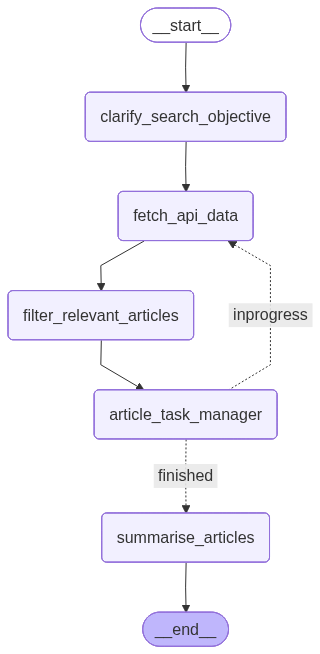

In [48]:
from IPython.display import Image

display(Image(compiled_article_graph.get_graph().draw_mermaid_png()))

### Running Article Agent

In [38]:

inputs = {
    "messages": [
        {
            "role": "user", 
            "content": f"use the following url globally {gnews_url_globally} , locally in china is {gnews_url_locally}, objective is : Chatbot news"
        }
    ]
}

results = compiled_article_graph.invoke(
inputs
)

clarify_search_objective starting...
results in clarify_search_objective are url_list=['https://gnews.io/api/v4/search?q=Technology&lang=en&max=40&apikey=2c4adab63b9954a566cfc901a4174ac4', 'https://gnews.io/api/v4/search?q=Technology&country=cn&lang=en&max=40&apikey=2c4adab63b9954a566cfc901a4174ac4'] processed_url_list=[] current_url='https://gnews.io/api/v4/search?q=Technology&lang=en&max=40&apikey=2c4adab63b9954a566cfc901a4174ac4' work_status='inprogress' objective='Identify and extract news articles specifically focused on advancements, updates, company announcements, or research developments related to AI chatbots, conversational agents, and large language model interfaces.'
results are : articles=[Article(description='Cloudflare CEO Matthew Prince warns AI agents could make it harder for small businesses to compete as autonomous systems increasingly influence consumer purchasing decisions., Technology & Science, Times Now', title='AI Agents Will Make It Harder For Small Businesses

In [50]:
results["summary"]

"below is either for global countries or chinese articles summary: 1. Analysts are questioning the sustainability of the massive capital expenditure by tech giants on AI data centre infrastructure. 2. Concerns have been raised comparing the current AI investment boom to the speculative trends observed during the dot-com era. 3. Australia has secured a significant defense technology contract with Canada for the supply of advanced long-range over-the-horizon radar systems. 4. There is emerging interest from international markets in Australian-made defense technologies, including autonomous drones like the Ghost Bat. 5. In India, the focus on educational quality remains centered on faculty expertise rather than just infrastructure or technology integration. 6. The Haryana Police in India has received national acclaim for deploying a technology-driven criminal procedure identification system. 7. Deeptech innovation in India is highlighted by startups like BioCompute, which is pioneering sy

In [52]:
results["articles_list"]

[[Article(description="As technology giants race to pour billions into AI infrastructure, one veteran analyst says the industry may be repeating mistakes seen during the dot-com era. Citing IBM CEO Arvind Krishna's calculations, David Linthicum argues that the economics behind the massive AI buildout are becoming increasingly difficult to justify.", title="'The emperor has no clothes': Expert says Big Tech's AI data centre race may backfire", content='The artificial intelligence race has triggered one of the biggest spending sprees the technology sector has witnessed in decades. From Microsoft and Amazon to Google and Meta, companies are committing vast sums to data centres and computing infrastructure.', source_url='https://www.firstpost.com/tech/the-emperor-has-no-clothes-expert-says-big-techs-ai-data-centre-race-may-backfire-14024922.html', publishedAt='2026-06-22', country_name='India'),
  Article(description='The quality of faculty remains the strongest determinant of an education

In [53]:
gnews_url_locally

'https://gnews.io/api/v4/search?q=Technology&lang=cn&max=40&apikey=2c4adab63b9954a566cfc901a4174ac4'

'{"status":"ok","news":[{"id":"f0a5d151-145a-5e8b-9716-83273a4464a4","title":"Is there a World Cup match in Atlanta today? These teams take the pitch","description":"Morocco and Haiti are facing off inside the Atlanta Stadium on Wednesday in a Group C showdown for the World Cup. See what matches are left in\\u00a0...","url":"https://www.onlineathens.com/story/sports/soccer/worldcup/2026/06/24/what-teams-are-playing-in-the-world-cup-in-atlanta-today-see-schedule/90673594007/","author":"","image":"None","language":"en","category":["regional"],"source_category":["regional"],"published":"2026-06-24 16:45:21 +0000"},{"id":"a1360206-0f6b-5b35-b879-9c99c24a98ef","title":"Amazon\'s Day 2 deals are live\\u2014here are the best Prime finds to shop - Online Athens","description":"Amazon Prime Day Day 2 is live with last-chance deals, restocks and deeper discounts across tech, home, beauty and more. Shop the best deals now.","url":"https://www.onlineathens.com/story/shopping/deals/prime-day/2026/0